#**1) Problem**

Employee attrition is a common problem in many organizations, where employees leave their jobs for different reasons. This can cause issues such as higher costs, loss of skilled workers, and lower productivity.

The main challenge is understanding why employees leave, since many factors can influence their decision, Even though companies have a lot of employee data, it is often difficult to use it to find clear patterns.

This problem is important because high employee turnover can negatively affect the organization’s performance and stability.


# **2) Data Mining Task**

The problem of employee attrition is formulated as a data mining task using two techniques:

- **Classification:** Used to predict whether an employee will
  leave the company or stay, based on historical employee data.
  Decision Tree models with Gini Index and Entropy are applied
  for this purpose.

- **Clustering:** Used to group employees with similar
  characteristics in order to discover hidden patterns in the
  data. The K-Means algorithm is applied with different values
  of K (2, 3, and 4).

#**3) Data**
The dataset used in this project contains 74498 records (instances) and 24 attributes (features) related to employee information. These attributes include both numerical features (such as Age, Monthly Income, and Years at Company) and categorical features (such as Gender, Job Role, and Work-Life Balance).

The class lable is Attrition, which indicates whether an employee stayed or left the company:
- Attrition = No (employees who stayed): [39128] instances
- Attrition = Yes (employees who left): [35370] instances

**ٍSample of the dataset before preprocessing**

In [ ]:
import pandas as pd

# Load raw dataset
raw_df = pd.read_csv("Raw_dataset.csv")

# Create a copy for preprocessing
df_raw_copy = raw_df.copy()

# Display first rows of the RAW dataset
print("Raw Dataset Snapshot:")
display(raw_df.head())

Raw Dataset Snapshot:


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


## **4) Data Preprocessing:**
data preprocessing is a crucial step used to prepare raw data for analysis by improving its quality and transforming it into a suitable format for data mining techniques.

 Applied Techniques:
  * Normalization for numerical variables such as Age and Monthly
Income to standardize their ranges.
  * Discretization of continuous variables like Years at Company into categories to improve interpretability.
  * Label Encoding to convert categorical variables like Attrition and Work-Life Balance into numerical values for modeling.
  * Feature Selection using Random Forest to identify the most important features, such as Monthly Income and Age.

**ٍSample of the dataset after preprocessing**

In [ ]:
import pandas as pd
df = pd.read_csv("Preprocessed_data.csv")
df.head()

,Job Level,Marital Status,Distance from Home,Monthly Income,Company Tenure,Age,Years at Company,Remote Work,Work-Life Balance,Number of Dependents,Attrition
0,1,1,0.214286,0.279032,0.690476,0.317073,0.36,0,0,0.000000,1
1,1,0,0.204082,0.288682,0.150794,1.000000,0.06,0,3,0.500000,1
2,1,1,0.102041,0.464585,0.571429,0.146341,0.18,0,2,0.500000,1
3,1,2,0.265306,0.185150,0.380952,0.439024,0.12,1,2,0.333333,1
4,2,0,0.714286,0.240903,0.523810,0.926829,0.80,0,1,0.000000,1


In this step, we are performing a value count for the 'Attrition' column to understand the distribution of the target variable.

In [ ]:
print(df['Attrition'].value_counts())

Attrition
1    39128
0    35370
Name: count, dtype: int64


# **5) Data Mining Technique:**
For this project, two data mining techniques will be applied: classification and clustering

##**5.1) Classfication** <br>
 In this project, a Decision Tree Classifier will be applied because it is simple, effective, and easy to interpret. It can handle structured data and show how decisions are made based on the dataset features.

For implementation in Python, the scikit-learn package will be used:

* from sklearn.tree import DecisionTreeClassifier
* from sklearn.model_selection import train_test_split
* from sklearn.metrics import accuracy_score, confusion_matrix

First, the dataset will be divided into training and testing sets
 * using train_test_split().

Then, the Decision Tree model will be built using
* DecisionTreeClassifier().

Two splitting criteria will be tested:

* Entropy (Information Gain) using criterion='entropy'
* Gini Index using criterion='gini'

After training the model with
* .fit(X_train, y_train)

predictions will be generated using
* .predict(X_test).<br>

The model performance will then be evaluated using:

* accuracy_score() to measure prediction accuracy
* confusion_matrix() to compare actual and predicted classes

In [ ]:
## Loading Data :
##The preprocessed dataset was loaded to be used for the classification task.
import pandas as pd
df = pd.read_csv("Preprocessed_data.csv")
df.head()


,Job Level,Marital Status,Distance from Home,Monthly Income,Company Tenure,Age,Years at Company,Remote Work,Work-Life Balance,Number of Dependents,Attrition
0,1,1,0.214286,0.279032,0.690476,0.317073,0.36,0,0,0.000000,1
1,1,0,0.204082,0.288682,0.150794,1.000000,0.06,0,3,0.500000,1
2,1,1,0.102041,0.464585,0.571429,0.146341,0.18,0,2,0.500000,1
3,1,2,0.265306,0.185150,0.380952,0.439024,0.12,1,2,0.333333,1
4,2,0,0.714286,0.240903,0.523810,0.926829,0.80,0,1,0.000000,1


 Importing Required Libraries
The required libraries were imported to load the dataset, split the data, build the Decision Tree classifier, evaluate the model, and visualize the decision tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn import tree


The dataset was divided into input features and the target variable. The target variable is Attrition.

In [ ]:
fn = df.columns.tolist()
fn.remove("Attrition")

X = df[fn]
y = df["Attrition"]

print("Features:")
print(fn)
print("\nTarget:")
print(y.name)

Features:
['Job Level', 'Marital Status', 'Distance from Home', 'Monthly Income', 'Company Tenure', 'Age', 'Years at Company', 'Remote Work', 'Work-Life Balance', 'Number of Dependents']

Target:
Attrition


####**5.1.1) Gini Index**

  **The first experiment**

 **90%** of the data was used for **training** and **10%** for **testing**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=1, stratify=y
)

model_gini_90 = DecisionTreeClassifier(criterion="gini", random_state=1)

model_gini_90.fit(X_train, y_train)

y_pred = model_gini_90.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.645503355704698
[[2212 1325]
 [1316 2597]]


The Decision Tree classifier using the Gini index was applied using a 90/10 train-test split. The model achieved an accuracy of 64.55%.

The confusion matrix shows that the model correctly classified 2212 employees who stayed and 2597 employees who left the company. However, some misclassifications occurred, with 1325 employees predicted as leaving while they actually stayed, and 1316 employees predicted as staying while they actually left.

 **The seconed experiment**

  **80%** of the data was used for **training** and **20%** for **testing**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

model_gini_80 = DecisionTreeClassifier(criterion="gini", random_state=1)

model_gini_80.fit(X_train, y_train)

y_pred = model_gini_80.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.641744966442953
[[4431 2643]
 [2695 5131]]


The Decision Tree classifier using the Gini index was also evaluated using an 80/20 train-test split. The model achieved an accuracy of 64.17%.

According to the confusion matrix, the model correctly classified 4431 employees who stayed and 5131 employees who left the company. However, some misclassifications occurred, where 2643 employees were predicted as leaving while they actually stayed, and 2695 employees were predicted as staying while they actually left.

**The third experiment**

 **70%** of the data was used for **training** and **30%** for **testing**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

model_gini_70 = DecisionTreeClassifier(criterion="gini", random_state=1)

model_gini_70.fit(X_train, y_train)

y_pred = model_gini_70.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6457718120805369
[[6666 3945]
 [3972 7767]]


The Decision Tree classifier using the Gini index was also evaluated using a 70/30 train-test split. The model achieved an accuracy of 64.58%.

The confusion matrix shows that 6666 employees who stayed and 7767 employees who left the company were correctly classified. However, some misclassifications occurred, where 3945 employees were predicted as leaving while they actually stayed, and 3972 employees were predicted as staying while they actually left.

####**5.1.2) IG Entropy**

 **The first experiment**

  **90%** of the data was used for **training** and **10%** for **testing**.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=1)

model_entropy=DecisionTreeClassifier(criterion="entropy", random_state=1)

model_entropy.fit(X_train, y_train)

y_pred=model_entropy.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6459060402684563
[[2229 1276]
 [1362 2583]]


The Decision Tree classifier using the Entropy criterion was also evaluated using an 90/10 train-test split. The model achieved an accuracy of 64.59%

According to the confusion matrix, the model correctly classified (2229) employees who stayed and (2583) employees who left the company. However, some misclassifications occurred, where (1276 ) employees were predicted as leaving while they actually stayed, and (1362) employees were predicted as staying while they actually left.

**The second experiment**

 **80%** of the data was used for **training** and **20%** for **testing**.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

model_entropy=DecisionTreeClassifier(criterion="entropy", random_state=1)

model_entropy.fit(X_train, y_train)

y_pred=model_entropy.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6432885906040269
[[4377 2658]
 [2657 5208]]


The Decision Tree classifier using the Entropy criterion was evaluated using an 80/20 train-test split. The model achieved an accuracy of 64.33%.

According to the confusion matrix, the model correctly classified 4,377 employees who stayed and 5,208 employees who left the company. However, some misclassifications occurred, where 2,658 employees who actually stayed were predicted as leaving, and 2,657 employees who actually left were predicted as staying.

**The third experiment**

**70%** of the data was used for **training** and **30%** for **testing**.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

model_entropy=DecisionTreeClassifier(criterion="entropy", random_state=1)

model_entropy.fit(X_train, y_train)

y_pred=model_entropy.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6501565995525727
[[6622 3973]
 [3846 7909]]


The Decision Tree classifier using the Entropy criterion was also evaluated using an 80/20 train-test split. The model achieved an accuracy of 65.01%

According to the confusion matrix, the model correctly classified (6622) employees who stayed and (7909) employees who left the company. However, some misclassifications occurred, where (3973 ) employees were predicted as leaving while they actually stayed, and (3846) employees were predicted as staying while they actually left.

---------------------------------------------------------------------------------------------------------------------------------------------------------------

##**5.2) Clustring**
The clustering technique will be used to group similar records in the dataset without using the class label. In this project, K-Means clustering will be applied to discover hidden patterns and segment the data into clusters.

For implementation in Python, the following packages will be used:

*   from sklearn.cluster import KMeans
*   import matplotlib.pyplot as plt
*   import seaborn as sns
*   from sklearn.metrics import silhouette_score
*   from yellowbrick.cluster import SilhouetteVisualizer

Since K-Means works with numeric data, only numerical attributes will be selected using:

*   df.select_dtypes(include=['number'])

Then, the clustering model will be created for three values of K (2, 3, and 4) using:
*   KMeans(n_clusters=k, random_state=42, n_init=10)

The clusters will be assigned using
*  .fit_predict().

The clustering results will be visualized using a scatter plot with Matplotlib and Seaborn, for example by plotting Age versus Monthly Income and coloring the points by cluster.

Finally, the clustering quality will be examined using two metrics:

*  inertia: measures how compact the formed clusters are, obtained through k_model.inertia_
*  Silhouette Score: measures how well each point fits its cluster, obtained through silhouette_score()
*  Elbow Method will also be used to visually identify the optimal number of clusters (K).

In [ ]:
# 1. Import necessary libraries for clustering and visualization
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Select only numerical columns for the model
# K-Means requires numerical data to calculate distances
numeric_df = df.select_dtypes(include=['number'])

In [ ]:
# 1. Drop the class label column ('Attrition') to ensure the model focuses only on patterns
# We store the result in a new variable to keep the original numeric data intact
numeric_df_final = numeric_df.drop(columns=['Attrition'])



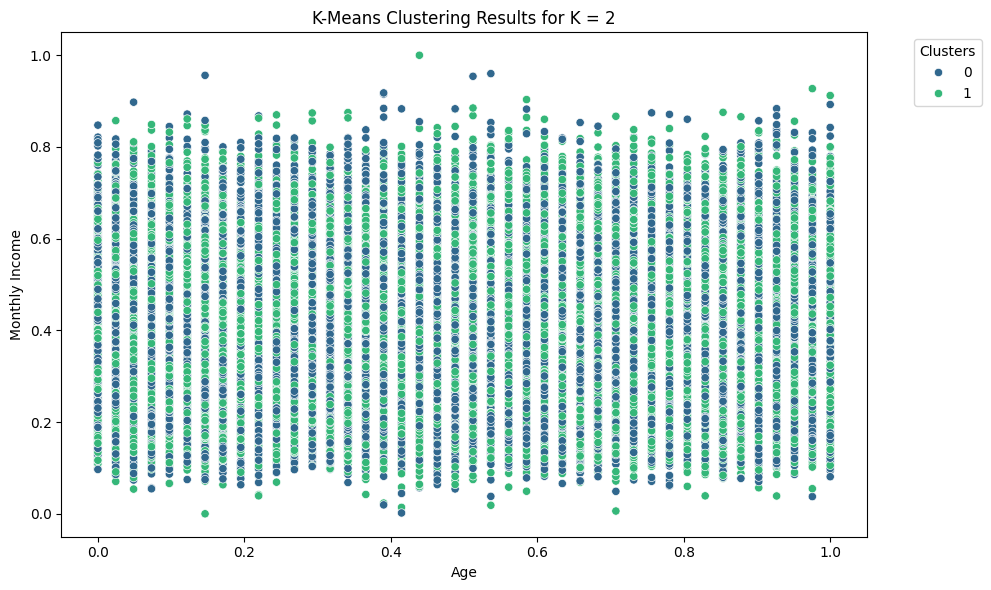

Total within-cluster sum of square (Inertia) for K=2: 129586.72264646852


In [ ]:
# Initialize and fit the KMeans model for K = 2
k2_model = KMeans(n_clusters=2, random_state=42, n_init=10)
df['K_Cluster_2'] = k2_model.fit_predict(numeric_df_final)

# Visualization: Age vs Monthly Income
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Monthly Income', hue='K_Cluster_2', palette='viridis')

# Format Legend and Titles
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('K-Means Clustering Results for K = 2')
plt.tight_layout()
plt.show()

# Output Inertia for Task 4
print(f"Total within-cluster sum of square (Inertia) for K=2: {k2_model.inertia_}")

**Interpretation of the Results**

At K=2, the algorithm divides the data into two clusters. However,
the scatter plot shows a very high level of overlap between Cluster 0
and Cluster 1 across all age and income ranges, with no clear
separation between them. This indicates that two clusters are not
sufficient to capture meaningful patterns in this dataset.

The inertia for K=2 is  129586.72, which is relatively high,
reflecting poor cluster compactness.


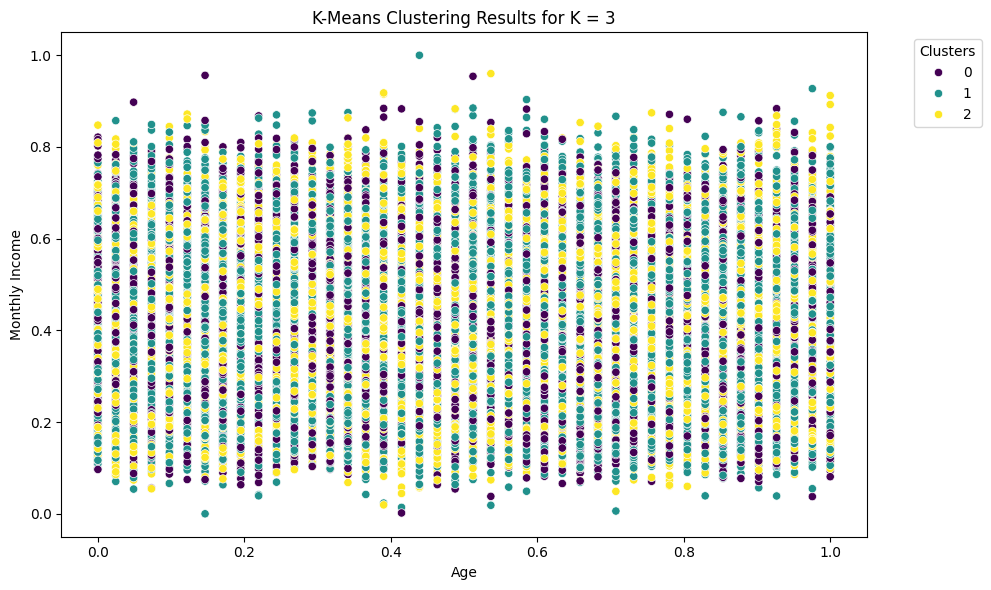

Total within-cluster sum of square (Inertia) for K=3: 113000.1569804909


In [ ]:
# Initialize and fit the KMeans model for K = 3
k3_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['K_Cluster_3'] = k3_model.fit_predict(numeric_df_final)

# Visualization: Age vs Monthly Income
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Monthly Income', hue='K_Cluster_3', palette='viridis')

# Format Legend and Titles
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('K-Means Clustering Results for K = 3')
plt.tight_layout()
plt.show()

# Output Inertia for Task 4
print(f"Total within-cluster sum of square (Inertia) for K=3: {k3_model.inertia_}")

**Interpretation of the Result**

At K=3, the algorithm divides the data into three clusters.
The scatter plot still shows a high level of overlap between
Cluster 0, Cluster 1, and Cluster 2 across all age and income
ranges, with no clear separation between them. However, compared
to K=2, the inertia decreased from  129586.72,to  113000.2,
which indicates a slight improvement in cluster compactness.

Despite this improvement, the three clusters remain heavily mixed,
suggesting that age and monthly income alone are not sufficient
to clearly separate employees into distinct groups.

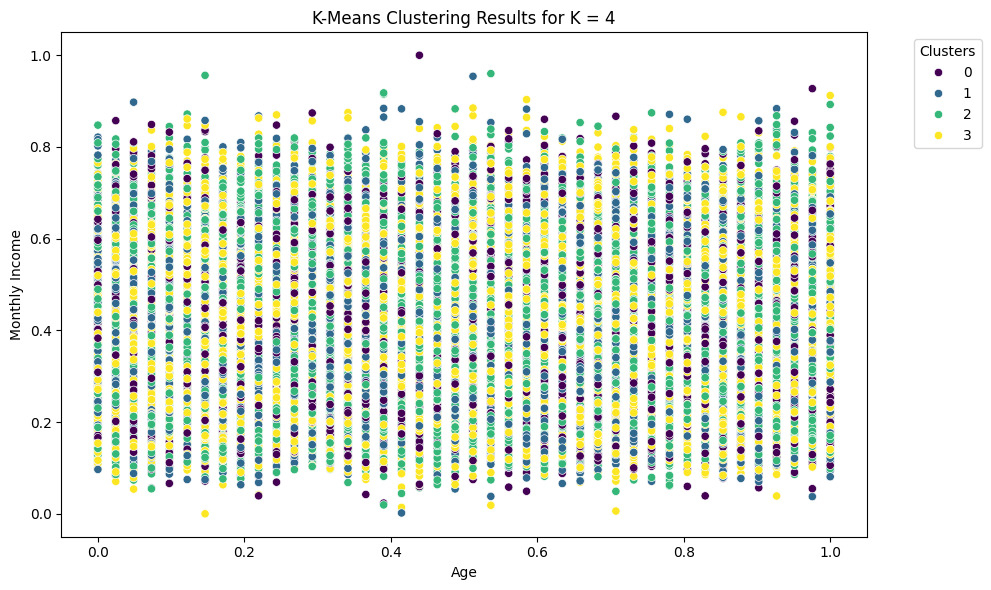

Total within-cluster sum of square (Inertia) for K=4: 100851.81780273841


In [ ]:
# Initialize and fit the KMeans model for K = 4
k4_model = KMeans(n_clusters=4, random_state=42, n_init=10)
df['K_Cluster_4'] = k4_model.fit_predict(numeric_df_final)

# Visualization: Age vs Monthly Income
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Monthly Income', hue='K_Cluster_4', palette='viridis')

# Format Legend and Titles
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('K-Means Clustering Results for K = 4')
plt.tight_layout()
plt.show()

# Output Inertia for Task 4
print(f"Total within-cluster sum of square (Inertia) for K=4: {k4_model.inertia_}")

**Interpretation of the Results**

At K=4, the algorithm divides the data into four clusters.
Compared to K=2 and K=3, the inertia decreased to 100851.82,
which reflects better compactness. However, the scatter plot
shows that the overlap between the four clusters remains high,
and no clear boundaries can be observed between them.

This suggests that increasing K improves the mathematical
performance but does not lead to visually distinct groups,
which indicates that Age and Monthly Income alone are not
strong enough features to separate employees into well defined
clusters.

## **6) Evaluation and Comparison**

 ### **6.1) Classification**
we applied three different data splits were applied for each classification technique (90/10, 80/20, and 70/30).

The Decision Tree model was evaluated using both Gini Index and Entropy criteria.

The results are presented in the following tables, which include the accuracy values and the confusion matrices for each model and partition.



### **confusion matrix**

The confusion matrix below shows the classification results for this model.

* **Gini index 90/10**

    [[2212 1325]<br>
    [1316 2597]]


---


* **Gini index 80/20**

   [[4431 2643]<br>
   [2695 5131]]


---


* **Gini index 70/30**

   [[6666 3945]<br>
   [3972 7767]]



---


* **IG Entropy 90/10**

  [[2229 1276]<br>
  [1362 2583]]


---


* **IG Entropy 80/20**

  [[4377 2658]<br>
  [2657 5208]]


---


* **IG Entropy 70/30**

  [[6622 3973]<br>
  [3846 7909]]



This table presents the accuracy results for both classification criteria

In [ ]:
from tabulate import tabulate

data = [
    ["90/10", 0.6455 , 0.6459],
    ["80/20", 0.6417 , 0.6433],
    ["70/30", 0.6458 , 0.6501]
]

headers = ["Split", "Gini", "Entropy"]

print(tabulate(data, headers=headers, tablefmt="grid"))

+---------+--------+-----------+
| Split   |   Gini |   Entropy |
+=========+========+===========+
| 90/10   | 0.6455 |    0.6459 |
+---------+--------+-----------+
| 80/20   | 0.6417 |    0.6433 |
+---------+--------+-----------+
| 70/30   | 0.6458 |    0.6501 |
+---------+--------+-----------+


**For Gini index**
 The results show that the classification performance is relatively similar across the three partitions, with accuracy values around 64%.

Among the tested partitions, **the 70/30 split achieved the highest accuracy.** This suggests that using a slightly larger testing set still provides reliable performance while maintaining stable classification results.

The decision tree below generated using the Gini index and the 70/30 data partition

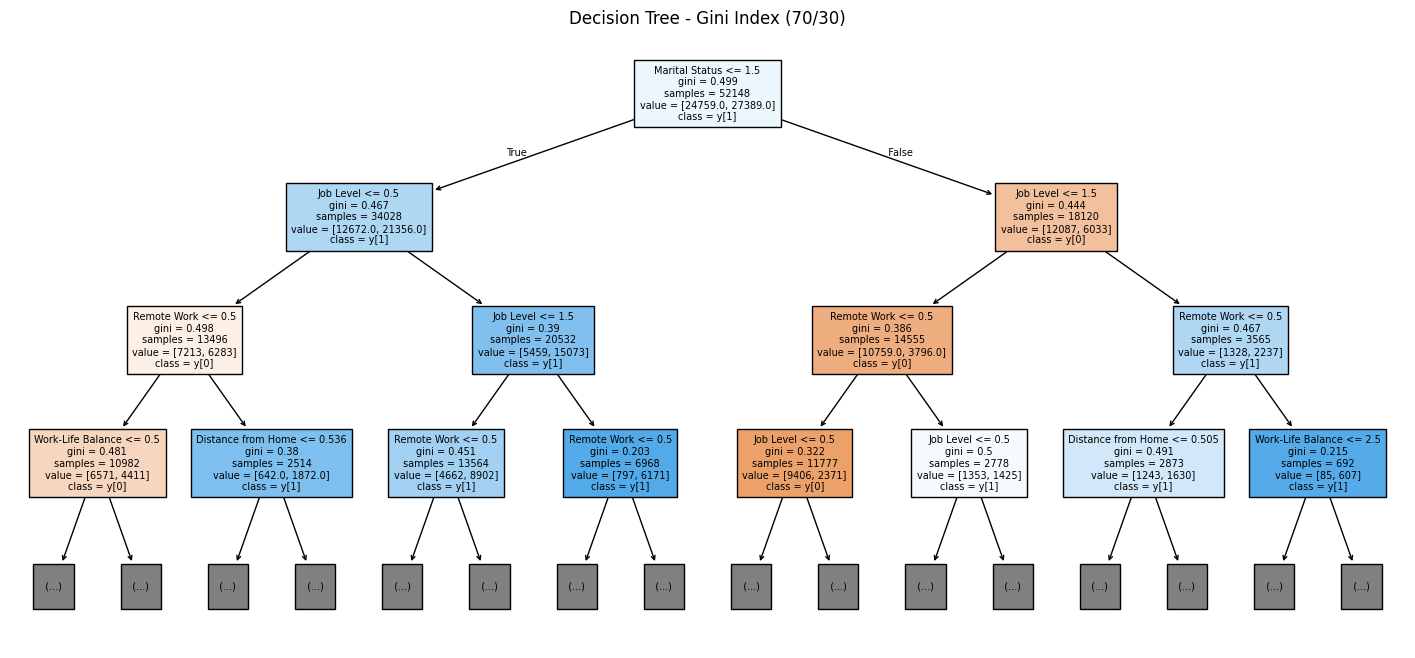

In [ ]:
plt.figure(figsize=(18,8))

tree.plot_tree(
    model_gini_70,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    max_depth=3,
    fontsize=7
)

plt.title("Decision Tree - Gini Index (70/30)")
plt.show()

**For IG Entropy**

Among the tested partitions, **the 70/30 split achieved the highest accuracy of 0.6501**, indicating slightly better performance compared to the other splits while maintaining stable classification results.

The decision tree below generated using the Entropy criterion and the 70/30 data partition

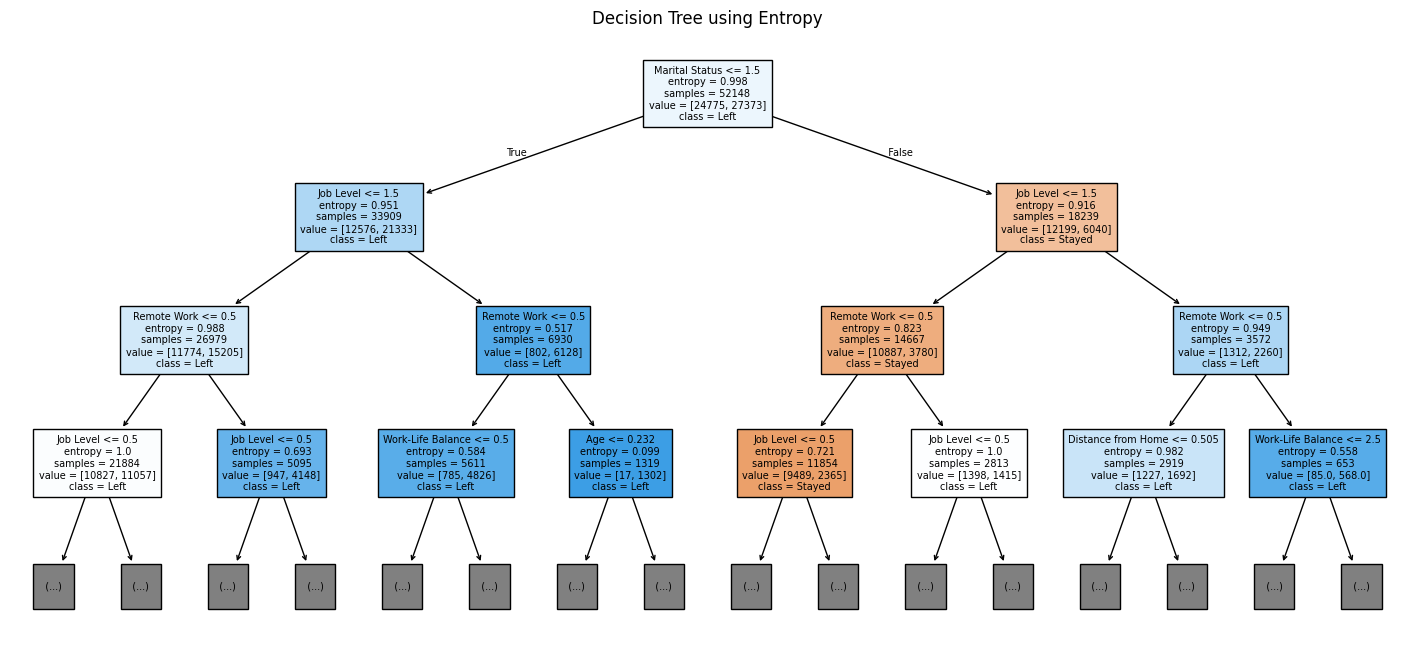

In [ ]:
# Create a figure to display the tree
plt.figure(figsize=(18,8))

# Plot the decision tree model that was trained using entropy
tree.plot_tree(
    model_entropy,               # The trained decision tree model
    feature_names=X.columns,     # Feature names from the dataset
    class_names=["Stayed","Left"], # Class labels for Attrition
    filled=True,                  # Color the nodes for better visualization
    max_depth=3,
    fontsize=7
)

# Add a title to the plot
plt.title("Decision Tree using Entropy")

# Display the tree
plt.show()

**Best Result:**

The best overall performance was achieved using the Entropy criterion with the 70/30 split, which obtained the highest accuracy of 0.6501. This indicates that this configuration performed slightly better compared to other combinations of splitting ratios and impurity measures.

### **6.2** **Clustering**

**Justification for Elbow Method and Silhouette Coefficient:**

Based solely on visual inspection catter plots and inertia values, it was not possible to confidently determine the optimal number of clusters K Each increase in K improves compactness mathematically, but the separation between groups remains visually weak. Therefore, we applied the Elbow Method and Silhouette Coefficient as quantitative evaluation techniques to objectively assess clustering performance and identify the optimal K based on a balance between compactness and separation quality.




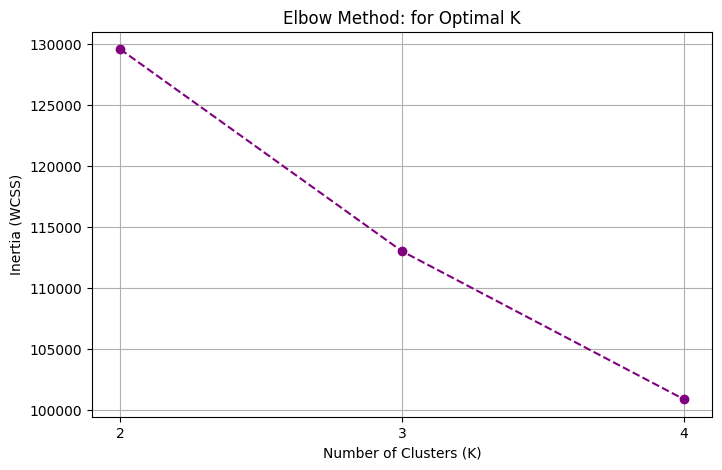

Inertia for K=2: 129586.72
Inertia for K=3: 113000.16
Inertia for K=4: 100851.82


In [ ]:
#  Applying the Elbow Method to find the best K
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# List to store the 'Inertia' (Within-Cluster Sum of Squares) for each K
inertias = []
# Testing at least three different sizes of K
k_values = [2,3,4]

# Loop through each K value to train the model and record performance
for k in k_values:
    # Initializing KMeans with a fixed random state for consistent results
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fitting the model to the numerical dataset prepared in Task 3
    model.fit(numeric_df_final)
    # Append the calculated inertia to our list
    inertias.append(model.inertia_)

# Creating the visual representation (Elbow Plot)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='purple', linestyle='--')
plt.title('Elbow Method: for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Display the numerical values for comparison
for i, k in enumerate(k_values):
    print(f"Inertia for K={k}: {inertias[i]:.2f}")


**Elbow Method Interpretation:**

The Elbow plot shows the inertia values for each value of K:
- K=2: 129586.72
- K=3: 113000.16
- K=4: 100851.82

The inertia decreases consistently as K increases. However, the plot does not show a clear "elbow" point where the decrease slows down significantly. Instead, the curve shows a gradual and steady decline, making it difficult to determine the optimal number of clusters based on this method alone.

Therefore, the Silhouette Coefficient will be used as an additional evaluation metric to help identify the best value of K.

In [ ]:
# Calculating Silhouette Coefficient for metric evaluation
from sklearn.metrics import silhouette_score

# List to store silhouette scores for comparison
silhouette_scores = []

# Evaluate each size of K to understand algorithm performance
for k in k_values:
    # Initializing the model and predicting cluster labels
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(numeric_df_final)

    # Calculate the silhouette score (measures separation quality)
    score = silhouette_score(numeric_df_final, labels)
    silhouette_scores.append(score)

# Visual representation of the silhouette results (Bar Chart)
plt.figure(figsize=(8, 5))
plt.bar([str(k) for k in k_values], silhouette_scores, color='skyblue')
plt.title('Comparison of Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# Display scores to discuss the algorithm performance
for i, k in enumerate(k_values):
    print(f"Silhouette Score for K={k}: {silhouette_scores[i]:.4f}")

**Silhouette Score Interpretation:**

The Silhouette scores for each value of K are as follows:
- K=2: 0.2479
- K=3: 0.2043
- K=4: 0.1970

The results show a clear trend: as K increases, the Silhouette Score consistently decreases. This indicates that adding more clusters weakens the separation between groups. K=2 achieves the highest score, meaning it provides the most well separated and cohesive clusters among the three candidates.

However, all three scores fall below the 0.25 threshold, which suggests that the dataset lacks strong natural groupings.

In [ ]:

from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# : Initialize the KMeans model
model = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Set up the SilhouetteVisualizer
# This tool helps in evaluating the density and separation between clusters
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer to the preprocessed numerical data
visualizer.fit(numeric_df_final)

# Finalize and render the figure
# This plot will show the silhouette coefficient for each sample in each cluster
visualizer.show()

# Output the average silhouette score
print(f"The average silhouette score for K=2 is: {visualizer.silhouette_score_}")

**Silhouette Plot for K=2 (Average Score: 0.2480)**

 Both clusters 0 and 1 have a similar size meaning the data is evenly distributed.
 Most samples in both clusters exceed the average score, and there are no negative values, which means no data points were completely misclassified.

The wide tails extending towards 0.0 indicate that many data points are near the boundaries between the two clusters, showing a lack of clear separation.


In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# : Initialize the KMeans model with t
model = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Set up the SilhouetteVisualizer
# This tool helps in evaluating the density and separation between clusters
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer to the preprocessed numerical data
visualizer.fit(numeric_df_final)

# Finalize and render the figure
# This plot will show the silhouette coefficient for each sample in each cluster
visualizer.show()

# Output the average silhouette score
print(f"The average silhouette score for K=3 is: {visualizer.silhouette_score_}")

  **Silhouette Plot for K=3 (Average Score: 0.2043):**

All three clusters have many data points with scores close to 0.0, meaning a large portion of the data is sitting right on the boundary between clusters.

Cluster 1 the middle green one has a significant portion of its data below the average silhouette line, indicating it is not well-defined.

Overall, the average score of 0.2043 confirms weak but acceptable
groupings, and K=3 was selected as the optimal number of clusters
because it provides more meaningful segmentation beyond a
simple two group split.

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# : Initialize the KMeans model w
model = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)

# Set up the SilhouetteVisualizer
# This tool helps in evaluating the density and separation between clusters
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer to the preprocessed numerical data
visualizer.fit(numeric_df_final)

# Finalize and render the figure
# This plot will show the silhouette coefficient for each sample in each cluster
visualizer.show()

# Output the average silhouette score
print(f"The average silhouette score for K=4 is: {visualizer.silhouette_score_}")

**Silhouette Plot for K=4 (Average Score: 0.1970):**

-The average silhouette score has dropped consistently from K=2 0.248 to K=3 0.204 and now K=4 0.197.

 Most clusters have  tails that are very thin near the average line, meaning very few data points are well-centered within their assigned clusters.

Cluster 0 & 3 These clusters have a large portion of their data falling below the average line, which signifies that they are not distinct groups.

In [ ]:
# Detailed Comparison for Selected K Values
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Based on Elbow and Silhouette, we select three candidate values (2, 3, 4)
chosen_K = [2, 3, 4]
cluster_details = []

for k in chosen_K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(numeric_df_final)

    inertia = kmeans.inertia_
    sil = silhouette_score(numeric_df_final, labels_k)

    cluster_details.append({"K": k, "WCSS": inertia, "Silhouette": sil})


cluster_results_df = pd.DataFrame(cluster_details).set_index('K').T
cluster_results_df.index = ['total within-cluster sum of square', 'Average Silhouette width']
cluster_results_df.columns = [f'K={k}' for k in chosen_K]

print("K-means Clustering Evaluation:")
display(cluster_results_df)

The table summarizes the clustering results for K=2, K=3, and K=4.
Inertia decreases as K increases, while the Average Silhouette
Width also decreases. Although K=2 achieves the highest Silhouette
Score (0.2479), K=3 was selected as the optimal number of clusters
because splitting the data into only two groups closely resembles
the original class label (Attrition: Yes/No), which does not add
new insights. K=3 introduces a third group that reveals additional
patterns in the data, making it more meaningful for analysis.

# **7) Findings and Discussion**

In this section, the results of classification and clustering
techniques are presented and discussed in order to interpret
employee attrition patterns and evaluate model performance.

#### **7.1) Classification Results**
One classification model was applied: Decision Tree, and its
performance was evaluated using accuracy across different data
splits (90/10, 80/20, and 70/30).

- The Decision Tree model was tested using two splitting criteria:
  Gini Index and Entropy.
- The results showed that Entropy performed slightly better than
  Gini Index, especially under the 70/30 split.
- The 70/30 split provided the most stable and reliable performance
  due to the balance between training and testing data.

The Decision Tree visualization revealed that the most important
features in predicting employee attrition are Marital Status,
Job Level, and Remote Work, as they appear at the top of the
tree and are used for the primary splits. This indicates that these factors have a strong influence on employee turnover decisions.

#### **7.2) Clustering Results**
K-Means clustering was applied using different values of K
(K=2, K=3, K=4), and the results were evaluated using Inertia,
Silhouette Score, and the Elbow Method.

- The Elbow Method showed a steady decrease in inertia without
  a clear elbow point, making it difficult to identify the
  optimal K based on this method alone.
- K=3 was selected as the optimal number of clusters because it
  provides more meaningful segmentation beyond a simple two-group
  split, despite K=2 having a slightly higher Silhouette Score.
- Increasing K to 4 reduced cluster quality and increased overlap
  between groups.
- All Silhouette scores remained below 0.25, confirming that the
  dataset does not have strong natural groupings.

#### **7.3) Interpretation of Results**
- Marital Status, Job Level, and Remote Work are the most
  influential factors in predicting employee attrition.
- The Decision Tree successfully predicts employee behavior
  based on these features.
- The clustering results showed significant overlap between
groups, suggesting that the dataset does not have strong natural
groupings based on the selected features.

#### **7.4) Best Model Selection**
- The best classification configuration is Decision Tree with
  **Entropy criterion under the 70/30 split**, due to its slightly
  higher accuracy.
- Although no clear natural groupings were found in the dataset,
  **K=3 was selected as the best clustering configuration** as it
  provides slightly more meaningful segmentation compared to
  K=2 and K=4.

#### **7.5) Visualization Support**
- Decision Tree diagrams were used to explain how classification
  decisions are made.
- Cluster scatter plots (Age vs Monthly Income) were used to
  visualize employee groupings.

#### **7.6) Relation to Research Paper**
The findings of this study are consistent with Mitravinda and
Shetty [1], who used the same IBM HR Analytics dataset and
analyzed the factors contributing to employee attrition. Their
study identified key employee attributes as significant predictors
of attrition. Similarly, our classification results confirm that Marital Status, Job Level, and Remote Work are among the most influential features in
predicting employee turnover, which aligns with the feature
importance findings reported in the referenced study.

Overall, the results demonstrate that classification is more effective than clustering for this dataset, as the Decision Tree model was able to achieve meaningful predictions, while clustering did not reveal strong natural groupings.

#**8) References**

[1] K. M. Mitravinda and S. Shetty, "Employee Attrition: Prediction,
Analysis Of Contributory Factors And Recommendations For Employee
Retention," in *Proc. ICWITE*, Bangalore, India, Dec. 2022,
doi: 10.1109/ICWITE57052.2022.10176235.

[2] I. Inggrianti and E. Mulyana, "A Web-Based Machine Learning
Application for Employee Attrition Prediction," in *Proc. 2025
19th International Conference on Telecommunication Systems,
Services, and Applications (TSSA)*, Yogyakarta, Indonesia,
Oct. 2025, doi: 10.1109/TSSA68467.2025.11303790.